# CodeAlpha Exploratory Data Analysis (EDA)

## Sample Superstore Dataset (CSV format)


## 1. Project Objective

The objective of this project is to explore and analyze a sales dataset using Python and Pandas. The analysis focuses on understanding the structure of the dataset, identifying missing values and duplicates, examining sales patterns, and extracting meaningful insights from the data.

The project also uses Matplotlib and Seaborn to visualize important trends and patterns.

## 2. Dataset Introduction

This project uses a sales dataset containing information about Customers, Products, Sales, Cities, Categories, Discounts, Profit, and other related attributes.

The dataset is explored using Python, Pandas, Matplotlib, and Seaborn to identify useful patterns and trends.

## 3. Research Questions

Before analyzing the dataset, the following questions were defined:

1. Which products generate the highest total sales?
2. Which cities contribute the most to total sales?
3. Which product category has the highest total sales?
4. How do sales change over time?
5. Which shipping mode is used most frequently?
6. Is there a relationship between discount and profit?
7. How is profit distributed, and are there potential outliers?
8. Is there a statistically significant relationship between time and sales?

## 4. Import Libraries



In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 5. Load Dataset

In [88]:
df = pd.read_csv("Sample-Superstore.1.csv")

In [89]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Products,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [90]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Products,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,243.160,2,0.0,72.9480


## 6. Dataset Structure

In [91]:
df.shape

(9994, 20)

### Dataset Information

The `info()` function is used to examine the columns, data types, and non-null values in the dataset.

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Products       9994 non-null   str    
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount       9994

### Statistical Summary

The `describe()` function provides statistical information about numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values.

In [93]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Check columns

In [94]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Products', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

## 7. Data types

In [95]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Products             str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## 8. Data Quality Checks

## Converting Data Type 
The Order Date and Ship Date columns are converted from string format to datetime format for time-based analysis.

In [96]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [97]:
df['Ship Date']= pd.to_datetime(df['Ship Date'])

In [98]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Products                    str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Missing Value Analysis

Missing values can affect data analysis and therefore need to be identified before performing further analysis.

In [99]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Products         0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64




The dataset contains no missing values.

## Duplicate Value Analysis

Duplicate records are checked to ensure that the same observation has not been included more than once.

In [100]:
df.duplicated().sum()

np.int64(0)

The dataset contains no duplicate rows.

## Data Validation

In [101]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Discount outside 0-1:", ((df['Discount'] < 0) | (df['Discount'] > 1)).sum())
print("Ship date before order date:", (df['Ship Date'] < df['Order Date']).sum())

Negative Sales: 0
Negative Quantity: 0
Discount outside 0-1: 0
Ship date before order date: 0


## Outlier Analysis

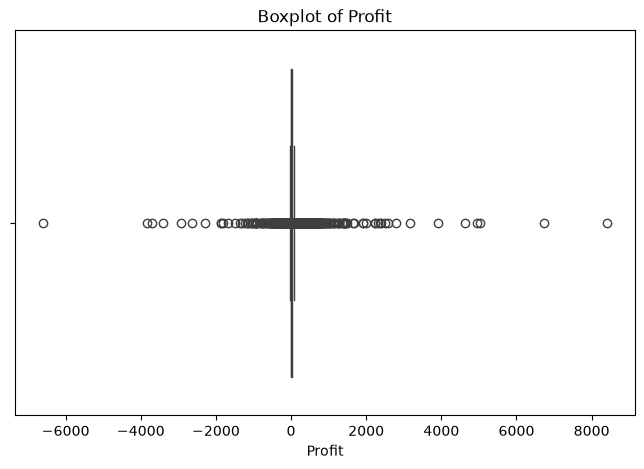

In [102]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Profit')
plt.title('Boxplot of Profit')
plt.xlabel('Profit')
plt.show()

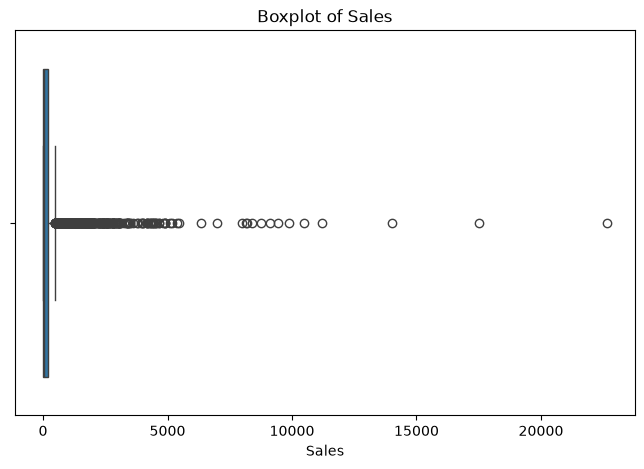

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Sales')
plt.title('Boxplot of Sales')
plt.xlabel('Sales')
plt.show()

## Observation
**The boxplots show the presence of extreme values in Sales and Profit. These values may represent unusually large transactions or significant gains/losses and should be considered during further analysis.**

### Potential Data Issues

The boxplots indicate extreme observations in Sales and Profit. These observations are not automatically considered errors because unusually large transactions or losses may be legitimate business events.

Further analysis could investigate whether these observations are associated with specific products, customers, cities, discounts, or other factors.

## 9. Exploratory Data Analysis

The following questions are used to explore the dataset and identify meaningful patterns.

# Question 1: Which products generate the most sales?

In [104]:
df['Products'].unique()

<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

In [105]:
products_sales = df.groupby('Products')['Sales'].sum().sort_values(ascending=False)

In [106]:
products_sales.head()

Products
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

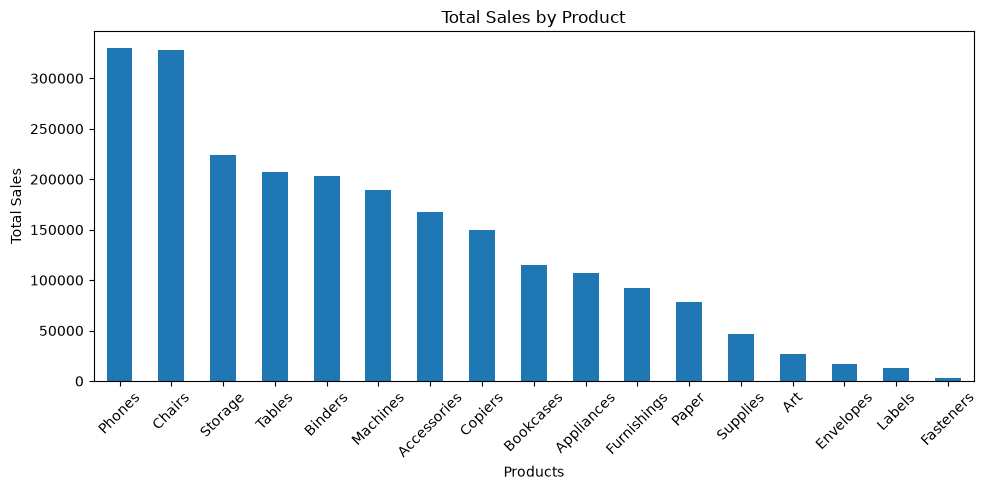

In [107]:
products_sales.plot(kind='bar', figsize=(10,5))
plt.title('Total Sales by Product')
plt.xlabel('Products')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The chart shows the total sales generated by each product. **Phones generated the highest total sales among the products, with approximately $330,007 in sales.**

# Question 2: Which are the top 10 cities by sales?

In [108]:
city_sales= df.groupby('City')['Sales'].sum().sort_values(ascending=False)

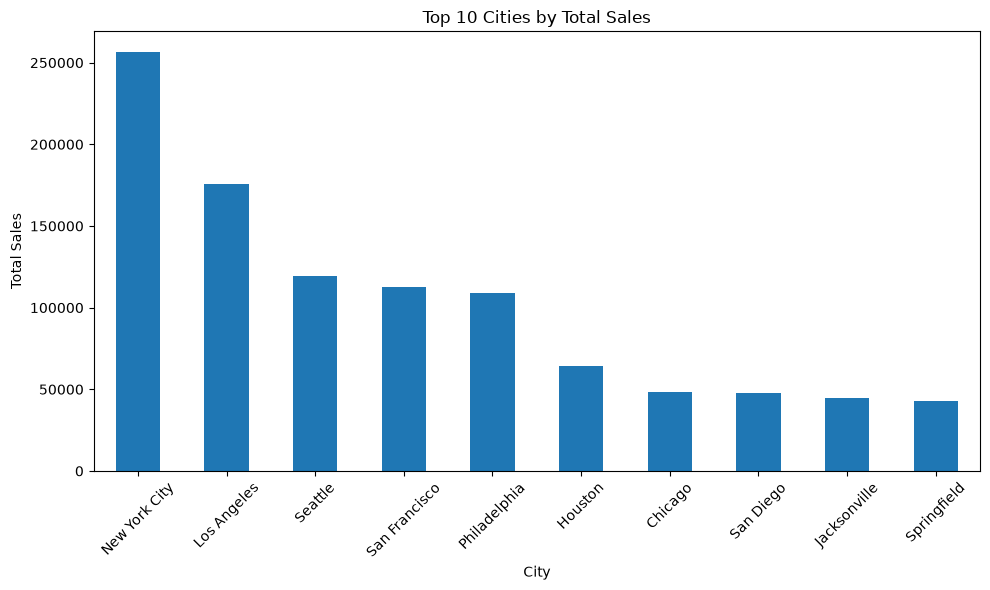

In [109]:
top_10 = city_sales.head(10)

top_10.plot(kind='bar', figsize=(10,6))

plt.title('Top 10 Cities by Total Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The visualization compares total sales across the top 10 cities. **New York City, with the highest value, represents the highest total sales in the dataset.**

# Question 3: Which category performs best?

In [110]:
category_sales= df.groupby('Category')['Sales'].sum().sort_values(ascending=False)


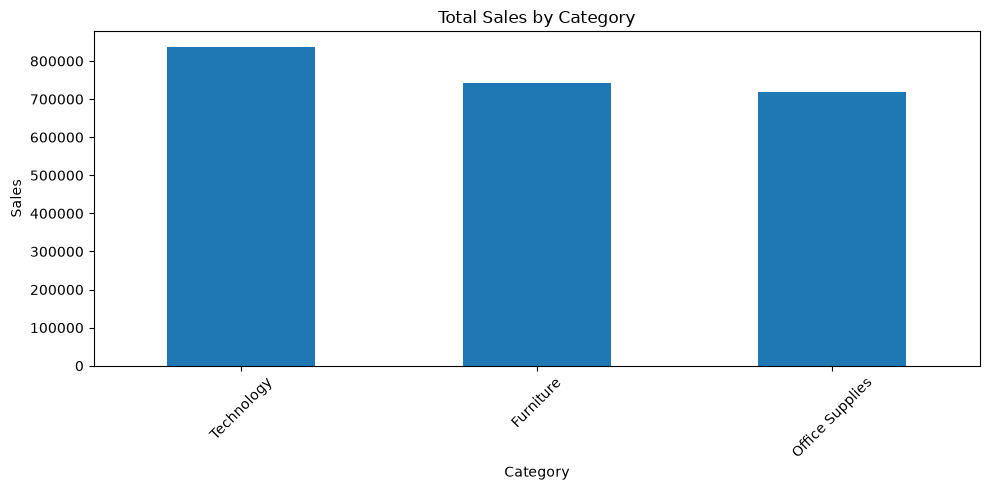

In [111]:
category_sales.plot(kind='bar', figsize=(10,5))
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Observation
The chart shows the total sales generated by each category.**Technology has the highest total sales among the three categories, followed by Furniture and Office Supplies.**

# Question 4: How do sales change over time?



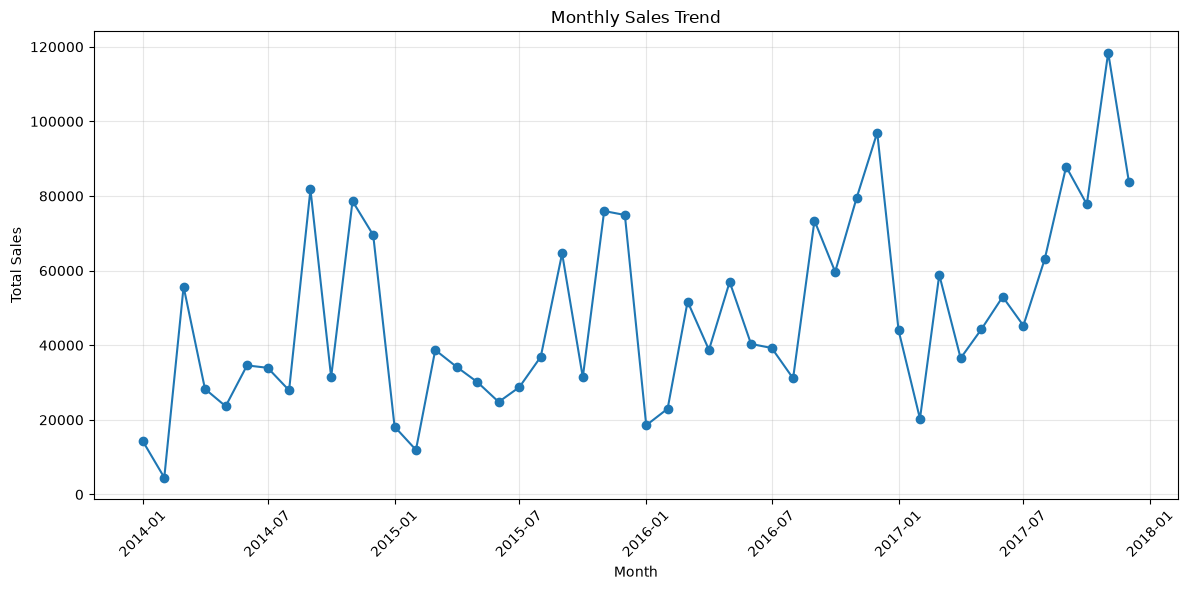

In [112]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observation
**Sales show an overall upward tendency over time, although there are substantial fluctuations across individual periods.**

# Question 5: Which ship mode is used most frequently?


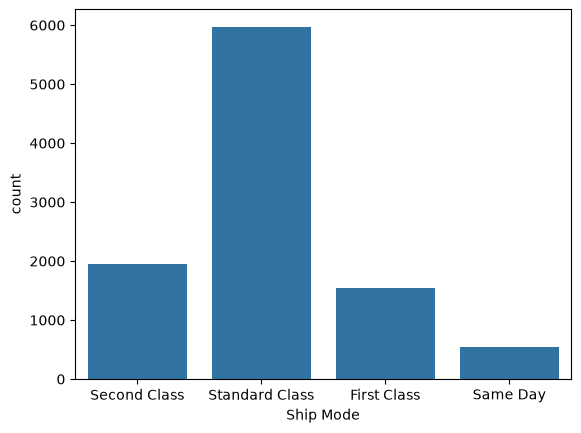

In [113]:
sns.countplot(data=df, x='Ship Mode')
plt.show()

# Observation

The count plot shows the frequency of records for each shipping mode. It can be observed that **Standard Class is the most frequently used shipping mode**, indicating that it is the preferred shipping method for most orders.



# Question 6: What is the relationship between discount and profit?

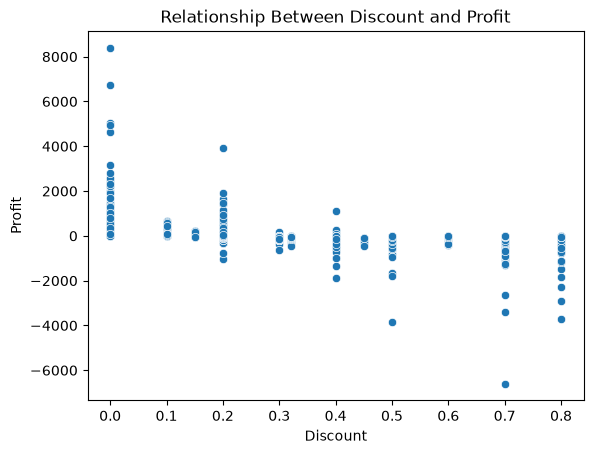

In [114]:
sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

In [115]:
df['Discount'].corr(df['Profit'])

np.float64(-0.2194874563717678)

# Observation
  
The scatter plot shows the relationship between Discount and Profit. It can be observed that **higher discount levels are generally associated with negative profits, while lower discount levels show more positive profits. The results indicate that higher discount levels are associated with lower profit in this dataset. However, this analysis does not establish a causal relationship.**

# Question 7: What is the distribution of profits?

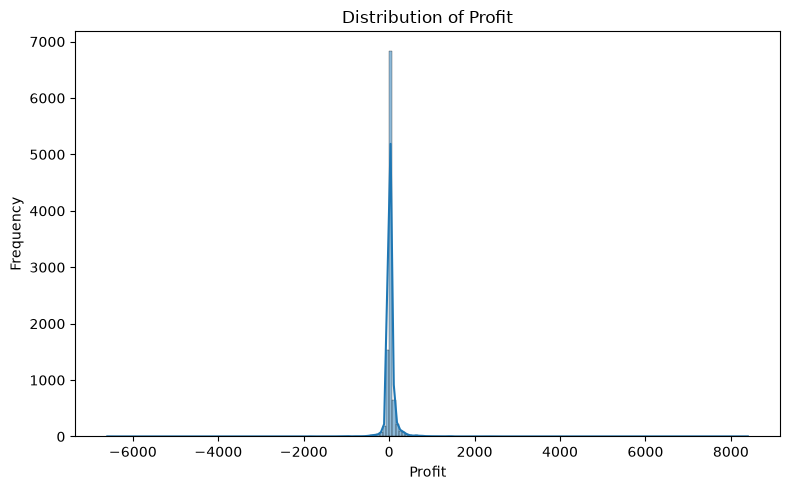

In [116]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Profit', kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Observation
**The profit distribution is concentrated around lower profit values, with some extreme positive and negative values. This indicates that profit varies substantially across transactions and contains potential outliers.**

## 10. Hypothesis Testing

## Hypothesis

H₀: There is no monotonic relationship between the two variables in the population.

H₁: There is a monotonic relationship between the two variables in the population.

## Test

Spearman correlation

## Significance level

α = 0.05

### Why Spearman Correlation?

Spearman correlation was selected because it measures the strength and direction of a monotonic relationship and does not require the variables to follow a normal distribution. It is appropriate for examining whether variables tend to increase or decrease together in a monotonic way.

### Statistical Interpretation

A statistically significant p-value indicates evidence of an association in the sample. It does not establish causation.

## Time vs Sales

In [117]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [118]:
daily_sales['Day_Number'] = range(len(daily_sales))

### Note

For the time-based hypothesis test, each unique order date was assigned a sequential day number. This provides a simple measure of temporal progression. The Spearman correlation therefore evaluates whether daily sales tend to increase or decrease monotonically over the observed period. This should be interpreted as an association with time rather than evidence of causation.

In [119]:
from scipy.stats import spearmanr


In [120]:
correlation, p_value = spearmanr(
    daily_sales['Day_Number'],
    daily_sales['Sales']
)

print("Spearman Correlation:", correlation)
print("P-value:", p_value)

Spearman Correlation: 0.2320137970933181
P-value: 1.3976216863795617e-16


In [121]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant relationship between time and sales.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between time and sales.")

Reject the null hypothesis.
There is a statistically significant relationship between time and sales.


## Hypothesis Conclusion¶
**The p-value is less than 0.05. Therefore, we reject the null hypothesis. There is a statistically significant weak positive association between time and daily sales in this dataset**.

## Discount vs Profit

In [122]:
correlation, p_value = spearmanr(df['Discount'], df['Profit'])

print("Spearman Correlation:", correlation)
print("P-value:", p_value)

Spearman Correlation: -0.5433501822306213
P-value: 0.0


In [123]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant relationship between Discount and Profit.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between Discount and Profit.")

Reject the null hypothesis.
There is a statistically significant relationship between Discount and Profit.


### Hypothesis Conclusion

The Spearman correlation test showed a statistically significant negative relationship between Discount and Profit (ρ = −0.543, p < 0.001). Therefore, the null hypothesis (H₀) is rejected, providing evidence of a monotonic association between discount and profit in the dataset.

The negative correlation indicates that higher discount levels tend to be associated with lower profit. **However, this analysis does not establish a causal relationship.** Other factors may also influence profit, and further analysis would be required to determine whether changes in discount directly cause changes in profit.



## 11. Key Findings

1. **Technology was the highest-selling category**, indicating strong overall sales performance compared with the other categories.

2. **Phones generated approximately $330,007 in sales**, making them one of the strongest-performing products in the dataset.

3. **Sales showed a weak positive relationship with time (Spearman ρ ≈ 0.232)**, suggesting that sales generally increased over time, although the 
relationship was not strong.

4. **Discount and profit showed a moderate negative relationship (Spearman ρ ≈ −0.543)**, indicating that higher discounts were generally associated with lower profits.

5. **The relationship between discount and profit was statistically significant (p < 0.001)**, providing statistical evidence that the observed association is unlikely to be due to random variation alone.

6. **The visualizations helped identify trends, differences, and potential anomalies in the sales data**, providing useful insights for understanding overall business performance.



## 12. Conclusions

The exploratory data analysis provided useful insights into the sales dataset and revealed several important patterns. The analysis showed that **Technology generated the highest total sales among the three categories**, while **Phones were the highest-selling product** based on total sales. The analysis of cities also identified differences in sales performance across locations, with **New York City recording the highest total sales among the cities**.

The monthly sales analysis showed an **overall upward tendency in sales over time**, although sales fluctuated across individual periods. The shipping analysis showed that **Standard Class was the most frequently used shipping mode**.

The analysis also identified a **negative relationship between discount and profit**. The Spearman correlation indicated a moderate negative association, and the hypothesis test showed that this relationship was statistically significant at the 5% significance level. Similarly, the analysis found a **weak positive association between time and daily sales**, which was also statistically significant.

Overall, the analysis demonstrates how data cleaning, visualization, descriptive analysis, and statistical testing can be used together to identify meaningful patterns in sales data. The findings can help in understanding sales performance, product demand, sales trends, and the relationship between discounting and profitability.
